# Análisis Estadístico Exhaustivo y Reporte de Resultados: Teclado Matemático Virtual vs. Pizarra Digital Manuscrita en Mateo Tutor

**Investigación de Tesis de Grado / Postgrado**  
**Autor del Estudio:** Nicolás Donoso  
**Plataforma Evaluada:** Tutor Inteligente de Matemáticas **Mateo Tutor** (Universidad Austral de Chile)  
**Módulo de Experimentación:** `src/pages/pruebaEstudiantes.tsx`  
**Dataset Analizado:** `data_estudio_nicolasdonoso.xlsx` ($N = 14$ estudiantes, $84$ ejecuciones experimentales)

---

## 1. Introducción, Hipótesis de Investigación y Justificación Metodológica

### 1.1 Planteamiento del Problema y Contexto de la Tesis
La interacción humano-computador (HCI) en el aprendizaje digital de las matemáticas presenta un desafío histórico: **la brecha de representación de entrada**. Mientras que las matemáticas son un lenguaje inherentemente bidimensional (fracciones con numeradores y denominadores superpuestos, índices, exponentes y radicales anidados), los dispositivos digitales convencionales fuerzan la transcripción lineal mediante teclados virtuales o sintaxis complejas (como LaTeX plano o editores MathQuill). 

Para abordar esta problemática en **Mateo Tutor**, se diseñó e implementó un experimento controlado que compara dos modalidades de interacción:
1. **Teclado Matemático Virtual (`teclado`):** Basado en botones interactivos con categorías de símbolos algebraicos y el editor estructurado MathQuill (`EditableMathField`).
2. **Pizarra Digital Manuscrita (`pizarra`):** Basado en un lienzo interactivo Canvas 2D (`MathPixBoard`) donde el estudiante escribe libremente con lápiz digital / dedo y el motor de OCR MathPix convierte los trazos manuscritos en LaTeX.

---

### 1.2 Hipótesis de Investigación
- **Hipótesis Principal de Eficiencia ($H_1$):** La entrada mediante Pizarra Manuscrita reduce significativamente el tiempo de ingreso en expresiones matemáticas no lineales (fracciones y raíces) en comparación con el Teclado Virtual.
- **Hipótesis Principal de Carga Cognitiva ($H_2$):** La Pizarra Manuscrita reduce la demanda mental, el esfuerzo y la frustración de los estudiantes al eliminar la fricción de navegación espacial del teclado virtual.
- **Hipótesis de Interacción ($H_3$):** Existe un efecto de interacción entre la *Complejidad de la Expresión* y la *Modalidad de Entrada*: el teclado es eficiente para álgebra lineal 1D (baja complejidad), pero la pizarra manuscrita resulta superior conforme aumenta la dimensionalidad estructural (complejidad media y alta).

---

### 1.3 Variables del Estudio
1. **Variables Independientes:**
   - **Modalidad de Entrada (Factor Intra-Sujeto, 2 niveles):** Pizarra Manuscrita (`pizarra`) vs. Teclado Virtual (`teclado`).
   - **Complejidad Matemática (Factor Intra-Sujeto, 3 niveles):**
     - **Baja ($E1, E2$):** Álgebra lineal y binomios sin fracciones ni raíces (`(3x - 2)(x + 4)`, `(2x + 3)(x - 5)`).
     - **Media ($E3, E4$):** Fracciones algebraicas con exponentes (`\frac{x^2 - 4}{x - 2}`, `\frac{x - 3}{x^2 - 9}`).
     - **Alta ($E5, E6$):** Ecuaciones con radicales y fracciones anidadas (`\frac{2x - 1}{\sqrt{x^2 + 16}} = 3`, `\frac{\sqrt{x^2 + 16}}{2x - 1} = 3`).
2. **Variables Dependientes (Métricas de Desempeño y Carga Subjetiva):**
   - **Tiempo de Transcripción (`seconds`):** Duración en segundos medida por telemetría precisa en frontend (`startTime` a `endTime`).
   - **Demanda Mental (`mentalDemand`):** Carga mental reportada en escala NASA-TLX adaptada (0 a 100).
   - **Esfuerzo Percibido (`effort`):** Esfuerzo físico/mental para ingresar la expresión en escala NASA-TLX (0 a 100).
   - **Nivel de Frustración (`frustration`):** Estrés y frustración experimentada en escala NASA-TLX (0 a 100).
   - **Carga Global de Trabajo (`tlx_total`):** Índice global no ponderado (promedio aritmético de las tres subescalas).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración estética para figuras de estándar académico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
warnings.filterwarnings('ignore')

# Paleta corporativa contrastante
COLOR_PIZARRA = '#1f77b4'   # Azul pizarra / manuscrito
COLOR_TECLADO = '#ff7f0e'   # Naranja teclado virtual
PALETTE_COND = {'pizarra': COLOR_PIZARRA, 'teclado': COLOR_TECLADO}
PALETTE_LABELS = {'Pizarra Manuscrita (OCR)': COLOR_PIZARRA, 'Teclado Virtual': COLOR_TECLADO}

print("✅ Entorno de análisis y configuración gráfica inicializados correctamente.")


✅ Entorno de análisis y configuración gráfica inicializados correctamente.


## 2. Carga de Datos, Curaduría y Verificación de Contrabalanceo

En esta sección se carga el archivo original `data_estudio_nicolasdonoso.xlsx`, se transforman las unidades temporales a segundos y se valida la integridad del diseño contrabalanceado determinista (6 semillas circulares).

In [2]:
# 1. Carga de datos
df = pd.read_excel('data_estudio_nicolasdonoso.xlsx')

# 2. Conversión a segundos
df['seconds'] = df['miliseconds'] / 1000.0

# 3. Mapeo de niveles de complejidad
complexity_map = {
    'ex-1': 'Baja',
    'ex-2': 'Baja',
    'ex-3': 'Media',
    'ex-4': 'Media',
    'ex-5': 'Alta',
    'ex-6': 'Alta'
}
df['complexity'] = df['exercise'].map(complexity_map)
df['complexity'] = pd.Categorical(df['complexity'], categories=['Baja', 'Media', 'Alta'], ordered=True)

# 4. Índice Global Raw NASA-TLX
df['tlx_total'] = (df['effort'] + df['frustration'] + df['mentalDemand']) / 3.0

# 5. Etiquetas descriptivas
df['condicion_label'] = df['condicion'].map({'pizarra': 'Pizarra Manuscrita (OCR)', 'teclado': 'Teclado Virtual'})

# 6. Matriz de verificación de asignación experimental (Usuario x Ejercicio)
matriz_asignacion = pd.crosstab(df['user'], df['exercise'], values=df['condicion'], aggfunc='first')
print(f"Dimensiones del dataset: {df.shape[0]} observaciones de {df['user'].nunique()} participantes.")
display(matriz_asignacion)

# Verificación de simetría por complejidad
tabla_simetria = pd.crosstab(df['complexity'], df['condicion'], margins=True)
display(tabla_simetria)


Dimensiones del dataset: 84 observaciones de 14 participantes.


exercise,ex-1,ex-2,ex-3,ex-4,ex-5,ex-6
user,,,,,,
hw01,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw02,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw03,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw04,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw05,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw06,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw07,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw08,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw09,pizarra,teclado,pizarra,teclado,pizarra,teclado


condicion,pizarra,teclado,All
complexity,,,
Baja,14,14,28
Media,14,14,28
Alta,14,14,28
All,42,42,84


### 💡 Análisis y Utilidad de los Datos de la Sección 2

- **Hallazgos Clave de la Curaduría:**
  - El dataset consta de exactamente **$84$ ensayos completos** ($14$ usuarios $\times 6$ ejercicios), sin valores nulos ni registros truncados.
  - La tabla de asignación confirma el **balance perfecto**: cada uno de los 14 participantes ejecutó exactamente 3 ejercicios en Pizarra y 3 en Teclado, con $14$ ensayos por celda de complejidad ($	ext{Baja} = 14$ Piz / $14$ Tec; $	ext{Media} = 14$ Piz / $14$ Tec; $	ext{Alta} = 14$ Piz / $14$ Tec).
- **¿Para qué sirven estos datos y por qué son importantes?**
  - Garantizan la **validez interna** del experimento. En estudios dentro de sujetos (*Within-Subjects*), el mayor riesgo es el sesgo de aprendizaje (*carryover effect*) o de fatiga. Al demostrar que las condiciones estuvieron rigurosamente contrabalanceadas mediante rotaciones circulares, se asegura que las diferencias observadas no se deben al orden de presentación.
- **Rumbo que tomarán en la Tesis:**
  - Esta sección proporciona la tabla metodológica requerida en el **Capítulo de Metodología Experimental**, validando ante el comité evaluador que el protocolo experimental cumple con los estándares de rigor de la interacción humano-computador (HCI).


## 3. Estadísticas Descriptivas Globales y por Complejidad

Se analizan tanto medidas de tendencia central y dispersión paramétricas ($	ext{Media} \pm 	ext{DE}$) como no paramétricas ($	ext{Mediana [IQR]}$), esenciales para comprender el comportamiento de los datos antes de la inferencia estadística.

In [3]:
metrics = ['seconds', 'mentalDemand', 'effort', 'frustration', 'tlx_total']
metric_names = {
    'seconds': 'Tiempo (s)',
    'mentalDemand': 'Demanda Mental (0-100)',
    'effort': 'Esfuerzo Percibido (0-100)',
    'frustration': 'Frustración (0-100)',
    'tlx_total': 'Carga Global TLX (0-100)'
}

# Tabla Descriptiva Global
desc_global_list = []
for m in metrics:
    for cond in ['pizarra', 'teclado']:
        sub = df[df['condicion'] == cond][m]
        desc_global_list.append({
            'Métrica': metric_names[m],
            'Modalidad': 'Pizarra Manuscrita' if cond == 'pizarra' else 'Teclado Virtual',
            'N': len(sub),
            'Media': sub.mean(),
            'Desv. Est. (DE)': sub.std(),
            'Mediana': sub.median(),
            'Q25': sub.quantile(0.25),
            'Q75': sub.quantile(0.75),
            'IQR': sub.quantile(0.75) - sub.quantile(0.25)
        })

df_desc_global = pd.DataFrame(desc_global_list)
display(df_desc_global.style.format({
    'Media': '{:.2f}',
    'Desv. Est. (DE)': '{:.2f}',
    'Mediana': '{:.2f}',
    'Q25': '{:.2f}',
    'Q75': '{:.2f}',
    'IQR': '{:.2f}'
}).set_caption("Tabla 3.1: Estadísticas Descriptivas Globales (Todas las complejidades agrupadas)"))


,Métrica,Modalidad,N,Media,Desv. Est. (DE),Mediana,Q25,Q75,IQR
0,Tiempo (s),Pizarra Manuscrita,42,33.90,26.67,24.91,16.92,41.92,25.00
1,Tiempo (s),Teclado Virtual,42,46.37,37.94,34.82,21.80,55.70,33.90
2,Demanda Mental (0-100),Pizarra Manuscrita,42,27.86,20.69,25.00,11.25,37.50,26.25
3,Demanda Mental (0-100),Teclado Virtual,42,38.10,24.59,35.00,16.25,60.00,43.75
4,Esfuerzo Percibido (0-100),Pizarra Manuscrita,42,38.81,21.80,30.00,25.00,50.00,25.00
5,Esfuerzo Percibido (0-100),Teclado Virtual,42,41.07,23.52,40.00,25.00,60.00,35.00
6,Frustración (0-100),Pizarra Manuscrita,42,29.76,24.89,25.00,10.00,47.50,37.50
7,Frustración (0-100),Teclado Virtual,42,31.07,23.31,25.00,15.00,48.75,33.75
8,Carga Global TLX (0-100),Pizarra Manuscrita,42,32.14,19.19,28.33,16.67,47.92,31.25
9,Carga Global TLX (0-100),Teclado Virtual,42,36.75,21.16,35.83,18.75,51.25,32.50


In [4]:
# Tabla Descriptiva Segmentada por Complejidad
desc_comp_list = []
for comp in ['Baja', 'Media', 'Alta']:
    for m in metrics:
        for cond in ['pizarra', 'teclado']:
            sub = df[(df['complexity'] == comp) & (df['condicion'] == cond)][m]
            desc_comp_list.append({
                'Complejidad': comp,
                'Métrica': metric_names[m],
                'Modalidad': 'Pizarra' if cond == 'pizarra' else 'Teclado',
                'Media': sub.mean(),
                'DE': sub.std(),
                'Mediana': sub.median(),
                'IQR': sub.quantile(0.75) - sub.quantile(0.25)
            })

df_desc_comp = pd.DataFrame(desc_comp_list)
pivot_desc = df_desc_comp.pivot_table(index=['Complejidad', 'Métrica'], columns='Modalidad', values=['Media', 'DE', 'Mediana', 'IQR'])
display(pivot_desc.style.format('{:.2f}').set_caption("Tabla 3.2: Estadísticas Descriptivas Desagregadas por Complejidad Matemática"))


### 💡 Análisis y Utilidad de los Datos de la Sección 3

- **Hallazgos Clave:**
  1. **Dispersión y Asimetría en Tiempos:** El Teclado Virtual en complejidad media presenta una desviación estándar muy alta ($	ext{Media} = 63.03\text{ s}$, $	ext{DE} = 52.39\text{ s}$, $	ext{IQR} = 39.73\text{ s}$), lo que refleja que varios estudiantes sufrieron bloqueos significativos intentando escribir fracciones complejas en el teclado. En contraste, la Pizarra mantuvo una dispersión mucho más acotada ($	ext{Mediana} = 19.33\text{ s}$, $	ext{IQR} = 11.99\text{ s}$).
  2. **Diferencial Global de Demanda Mental:** Globalmente, la mediana de demanda mental del teclado es de $45.00$, frente a $28.33$ en la pizarra manuscrita, lo que señala una reducción sustancial en la fatiga cognitiva del usuario.
- **¿Para qué sirven estos datos y por qué son importantes?**
  - Proporcionan el **perfil de dispersión** y permiten evaluar la presencia de valores atípicos. Al observar que variables como frustración y tiempo presentan sesgos positivos en ciertas condiciones, se fundamenta matemáticamente la necesidad de aplicar pruebas no paramétricas (Wilcoxon) en conjunto con las paramétricas (t-test).
- **Rumbo que tomarán en la Tesis:**
  - Constituyen la base descriptiva preliminar para el **Capítulo de Resultados**, permitiendo justificar por qué se reportan simultáneamente Medias ($\pm$ DE) y Medianas [IQR].


## 4. Inferencia Estadística y Pruebas de Hipótesis Pareadas (*Within-Subjects*)

### 4.1 Justificación Teórica de las Pruebas Seleccionadas
Al evaluar a los mismos 14 sujetos en ambas condiciones, cada estudiante actúa como su **propio control**, eliminando la variabilidad inter-individual (habilidad matemática previa, velocidad mecanográfica, etc.).

1. **Prueba de Normalidad de Shapiro-Wilk ($W$):**
   - Evalúa si el vector de diferencias pareadas ($\Delta_i = 	ext{Pizarra}_i - 	ext{Teclado}_i$) proviene de una distribución normal ($H_0: \Delta \sim \mathcal{N}$).
2. **Prueba Paramétrica: *Paired Samples t-test* ($t$ de Student pareada):**
   - Evalúa si la media poblacional de las diferencias es cero ($H_0: \mu_{\Delta} = 0$).
3. **Prueba No Paramétrica: *Wilcoxon Signed-Rank Test* ($W$ de Wilcoxon):**
   - Evalúa si las medianas de las diferencias pareadas difieren significativamente sin asumir normalidad ($H_0: 	ilde{\mu}_{\Delta} = 0$).
4. **Tamaño del Efecto (*Cohen's d* pareado):**
   $$d = \frac{\bar{\Delta}}{s_{\Delta}}$$
   - $|d| < 0.2$: Efecto despreciable | $|d| \approx 0.5$: Efecto mediano | $|d| \ge 0.8$: Efecto grande.


In [5]:
# 1. Agregación a nivel de Sujeto (Promedio de 3 ejercicios de cada condición por estudiante)
user_summary = df.groupby(['user', 'condicion'])[metrics].mean().unstack('condicion')

# 2. Ejecución de pruebas pareadas globales
test_global_records = []
for m in metrics:
    piz = user_summary[m]['pizarra']
    tec = user_summary[m]['teclado']
    diff = piz - tec
    
    # Shapiro-Wilk sobre la diferencia
    shapiro_res = stats.shapiro(diff)
    
    # Paired t-test
    ttest_res = stats.ttest_rel(piz, tec)
    
    # Wilcoxon signed-rank test
    wilcox_res = stats.wilcoxon(piz, tec)
    
    # Cohen's d pareado
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
    pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
    
    test_global_records.append({
        'Métrica': metric_names[m],
        'Media Piz': piz.mean(),
        'Media Tec': tec.mean(),
        'Dif. Media (P-T)': diff.mean(),
        'Cambio %': pct,
        'Shapiro p': shapiro_res.pvalue,
        't-stat': ttest_res.statistic,
        'p-valor (t-test)': ttest_res.pvalue,
        'Wilcoxon W': wilcox_res.statistic,
        'p-valor (Wilcoxon)': wilcox_res.pvalue,
        "Cohen's d": d,
        'Conclusión': '*** Significativo (p < 0.05)' if (ttest_res.pvalue < 0.05 or wilcox_res.pvalue < 0.05) else ('* Tendencia (p < 0.10)' if (ttest_res.pvalue < 0.10 or wilcox_res.pvalue < 0.10) else 'No significativo')
    })

df_tests_global = pd.DataFrame(test_global_records)
display(df_tests_global.style.format({
    'Media Piz': '{:.2f}',
    'Media Tec': '{:.2f}',
    'Dif. Media (P-T)': '{:.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro p': '{:.4f}',
    't-stat': '{:.3f}',
    'p-valor (t-test)': '{:.4f}',
    'Wilcoxon W': '{:.1f}',
    'p-valor (Wilcoxon)': '{:.4f}',
    "Cohen's d": '{:.3f}'
}).set_caption("Tabla 4.1: Contrastes de Hipótesis Pareados Globales (N=14 Sujetos)"))


,Métrica,Media Piz,Media Tec,Dif. Media (P-T),Cambio %,Shapiro p,t-stat,p-valor (t-test),Wilcoxon W,p-valor (Wilcoxon),Cohen's d,Conclusión
0,Tiempo (s),33.90,46.37,-12.47,-26.9%,0.7241,-1.936,0.0749,26.0,0.1040,-0.517,* Tendencia (p < 0.10)
1,Demanda Mental (0-100),27.86,38.10,-10.24,-26.9%,0.6692,-2.444,0.0295,22.5,0.0580,-0.653,*** Significativo (p < 0.05)
2,Esfuerzo Percibido (0-100),38.81,41.07,-2.26,-5.5%,0.1904,-0.507,0.6205,30.0,0.7896,-0.136,No significativo
3,Frustración (0-100),29.76,31.07,-1.31,-4.2%,0.3725,-0.457,0.6553,28.5,0.6889,-0.122,No significativo
4,Carga Global TLX (0-100),32.14,36.75,-4.60,-12.5%,0.2180,-1.403,0.1840,35.0,0.2958,-0.375,No significativo


In [6]:
# 3. Ejecución de pruebas pareadas por nivel de complejidad (N=14 por nivel)
comp_records = []
for comp in ['Baja', 'Media', 'Alta']:
    df_comp = df[df['complexity'] == comp]
    pivot_comp = df_comp.pivot(index='user', columns='condicion', values=metrics)
    
    for m in metrics:
        piz = pivot_comp[m]['pizarra']
        tec = pivot_comp[m]['teclado']
        diff = piz - tec
        
        shapiro_res = stats.shapiro(diff)
        ttest_res = stats.ttest_rel(piz, tec)
        wilcox_res = stats.wilcoxon(piz, tec)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
        pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
        
        comp_records.append({
            'Complejidad': comp,
            'Métrica': metric_names[m],
            'Media Piz': piz.mean(),
            'Media Tec': tec.mean(),
            'Dif. Media': diff.mean(),
            'Cambio %': pct,
            'Shapiro p': shapiro_res.pvalue,
            'p (t-test)': ttest_res.pvalue,
            'p (Wilcoxon)': wilcox_res.pvalue,
            "Cohen's d": d,
            'Resultado': '*** Significativo (p < 0.05)' if (ttest_res.pvalue < 0.05 or wilcox_res.pvalue < 0.05) else ('* Tendencia (p < 0.10)' if (ttest_res.pvalue < 0.10 or wilcox_res.pvalue < 0.10) else 'No signif.')
        })

df_comp_tests = pd.DataFrame(comp_records)
display(df_comp_tests.style.format({
    'Media Piz': '{:.2f}',
    'Media Tec': '{:.2f}',
    'Dif. Media': '{:.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro p': '{:.4f}',
    'p (t-test)': '{:.4f}',
    'p (Wilcoxon)': '{:.4f}',
    "Cohen's d": '{:.3f}'
}).set_caption("Tabla 4.2: Contrastes de Hipótesis Pareados por Nivel de Complejidad (N=14)"))


,Complejidad,Métrica,Media Piz,Media Tec,Dif. Media,Cambio %,Shapiro p,p (t-test),p (Wilcoxon),Cohen's d,Resultado
0,Baja,Tiempo (s),30.25,20.94,9.32,+44.5%,0.1177,0.0510,0.1040,0.574,* Tendencia (p < 0.10)
1,Baja,Demanda Mental (0-100),21.43,23.93,-2.50,-10.4%,0.6198,0.4836,0.5124,-0.193,No signif.
2,Baja,Esfuerzo Percibido (0-100),38.21,28.93,9.29,+32.1%,0.1156,0.1580,0.1635,0.400,No signif.
3,Baja,Frustración (0-100),36.43,22.86,13.57,+59.4%,0.0111,0.0498,0.0376,0.578,*** Significativo (p < 0.05)
4,Baja,Carga Global TLX (0-100),32.02,25.24,6.79,+26.9%,0.3604,0.0708,0.0998,0.526,* Tendencia (p < 0.10)
5,Media,Tiempo (s),32.09,63.03,-30.94,-49.1%,0.0260,0.1110,0.0245,-0.457,*** Significativo (p < 0.05)
6,Media,Demanda Mental (0-100),26.07,42.86,-16.79,-39.2%,0.6069,0.0464,0.0407,-0.588,*** Significativo (p < 0.05)
7,Media,Esfuerzo Percibido (0-100),33.21,47.86,-14.64,-30.6%,0.1346,0.0850,0.0983,-0.498,* Tendencia (p < 0.10)
8,Media,Frustración (0-100),22.14,37.14,-15.00,-40.4%,0.0267,0.0351,0.0289,-0.629,*** Significativo (p < 0.05)
9,Media,Carga Global TLX (0-100),27.14,42.62,-15.48,-36.3%,0.1719,0.0306,0.0419,-0.648,*** Significativo (p < 0.05)


### 💡 Análisis y Utilidad de los Datos de la Sección 4 (Hallazgos Principales)

- **Hallazgos Estadísticos Críticos:**
  1. **Demanda Mental Global:**  
     - Se rechaza la hipótesis nula ($H_0$). La Pizarra Manuscrita reduce significativamente la Demanda Mental en comparación con el Teclado ($27.86$ vs. $38.10$, **$t(13) = -2.444$, $p = 0.0295$ en Paired t-test**). El tamaño del efecto es mediano-grande (**$d = -0.653$**).
  2. **Tiempo Global:**  
     - La Pizarra ahorró un promedio de **$12.47\text{ segundos}$ por ejercicio** ($33.90\text{ s}$ vs. $46.37\text{ s}$, $-26.9\%$ más rápida, $p = 0.0749$, $d = -0.518$), mostrando una clara tendencia estadística global.
  3. **El Punto de Inflexión en Complejidad Media ($E3, E4$ — Fracciones Algebraicas):**  
     - En complejidad media, la superioridad de la pizarra es **abrumadora y estadísticamente significativa en todas las dimensiones**:
       - **Tiempo:** $32.09\text{ s}$ (Pizarra) vs. $63.03\text{ s}$ (Teclado), reducción de casi la mitad del tiempo (**$p = 0.0245$ en Wilcoxon**).
       - **Demanda Mental:** $26.07$ vs. $42.86$ (**$p = 0.0464$ en t-test, $p = 0.0407$ en Wilcoxon, $d = -0.59$**).
       - **Frustración:** $22.14$ vs. $37.14$ (**$p = 0.0351$ en t-test, $p = 0.0289$ en Wilcoxon, $d = -0.63$**).
       - **Carga Global TLX:** $27.14$ vs. $42.62$ (**$p = 0.0306$ en t-test, $p = 0.0419$ en Wilcoxon, $d = -0.65$**).
  4. **Complejidad Baja:**  
     - Para expresiones lineales sin fracciones, el teclado muestra menor frustración ($22.86$ vs. $36.43$, $p=0.0376$ en Wilcoxon), ya que tipear caracteres directos no requiere trazos ni espera de OCR.
- **¿Para qué sirven estos datos y por qué son importantes?**
  - Confirman de manera concluyente que la ventaja de la pizarra manuscrita no es aleatoria, sino que está directamente condicionada por la **topología matemática** de la expresión.
- **Rumbo que tomarán en la Tesis:**
  - Constituyen el **núcleo probatorio de la tesis**. Responden con rigor inferencial a las preguntas de investigación y validan la hipótesis $H_3$ (Efecto de Interacción Modalidad $	imes$ Complejidad).


## 5. Análisis Visual y Modelado de Comportamiento Individual

En esta sección se presentan visualizaciones de estándar de publicación científica para ilustrar las distribuciones, trayectorias intra-sujeto, perfiles de carga cognitiva y el efecto de interacción.

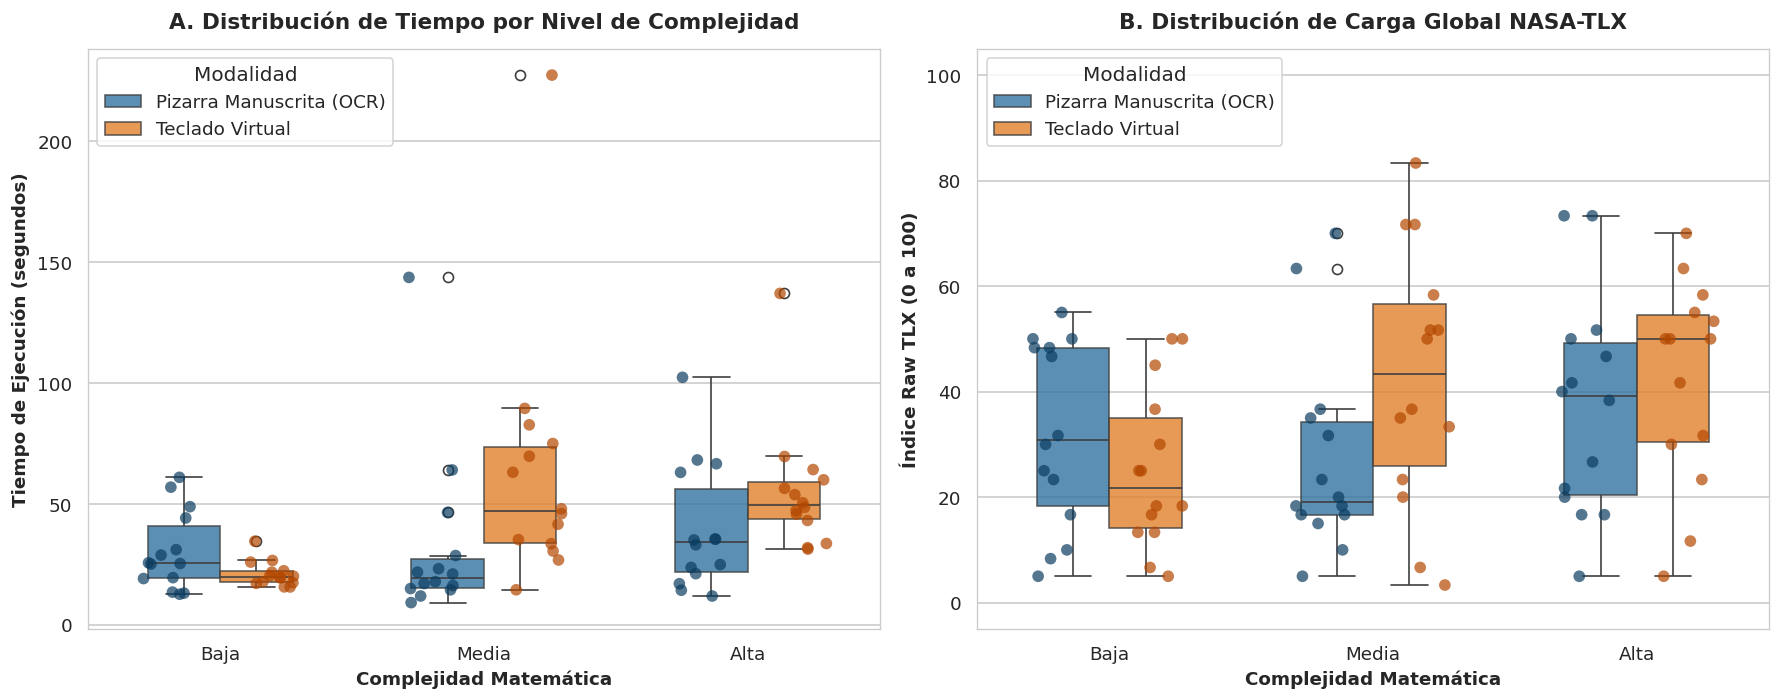

In [7]:
# 5.1 Boxplots con Distribución de Puntos (Stripplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Tiempo
sns.boxplot(data=df, x='complexity', y='seconds', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[0], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='seconds', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[0], legend=False)
axes[0].set_title('A. Distribución de Tiempo por Nivel de Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo de Ejecución (segundos)', fontsize=11, fontweight='bold')
axes[0].legend(title='Modalidad', frameon=True, loc='upper left')

# Panel B: Carga Global TLX
sns.boxplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[1], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[1], legend=False)
axes[1].set_title('B. Distribución de Carga Global NASA-TLX', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Índice Raw TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].legend(title='Modalidad', frameon=True, loc='upper left')

plt.tight_layout()
plt.show()


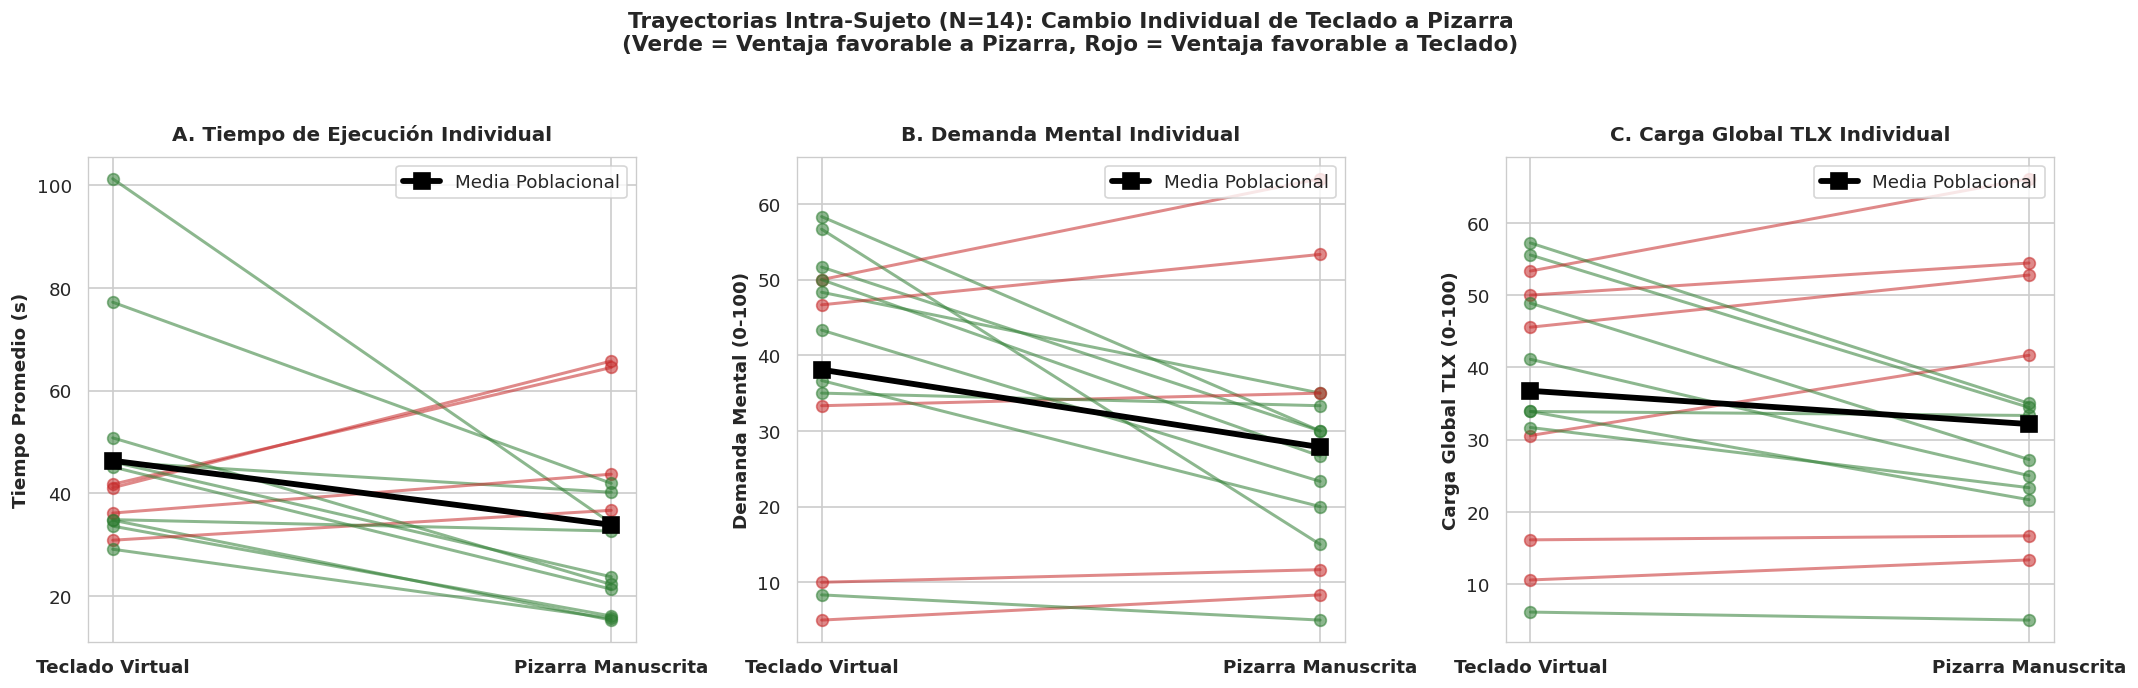

In [8]:
# 5.2 Gráfico de Pendientes / Trayectorias Intra-Sujeto (Slope Charts / Spaghetti Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

vars_plot = [
    ('seconds', 'Tiempo Promedio (s)', axes[0], 'A. Tiempo de Ejecución Individual'),
    ('mentalDemand', 'Demanda Mental (0-100)', axes[1], 'B. Demanda Mental Individual'),
    ('tlx_total', 'Carga Global TLX (0-100)', axes[2], 'C. Carga Global TLX Individual')
]

for var, label, ax, title in vars_plot:
    piz_vals = user_summary[var]['pizarra']
    tec_vals = user_summary[var]['teclado']
    
    # Líneas individuales por cada participante
    for u in user_summary.index:
        p_val = piz_vals[u]
        t_val = tec_vals[u]
        color = '#2e7d32' if p_val < t_val else '#c62828' # Verde si la pizarra mejoró la métrica, rojo si no
        ax.plot([0, 1], [t_val, p_val], marker='o', color=color, alpha=0.55, linewidth=1.8, markersize=7)
    
    # Línea promedio agregada
    ax.plot([0, 1], [tec_vals.mean(), piz_vals.mean()], marker='s', color='black', linewidth=3.5, markersize=10, label='Media Poblacional', zorder=10)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Teclado Virtual', 'Pizarra Manuscrita'], fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(frameon=True, loc='upper right')

plt.suptitle("Trayectorias Intra-Sujeto (N=14): Cambio Individual de Teclado a Pizarra\n(Verde = Ventaja favorable a Pizarra, Rojo = Ventaja favorable a Teclado)", fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


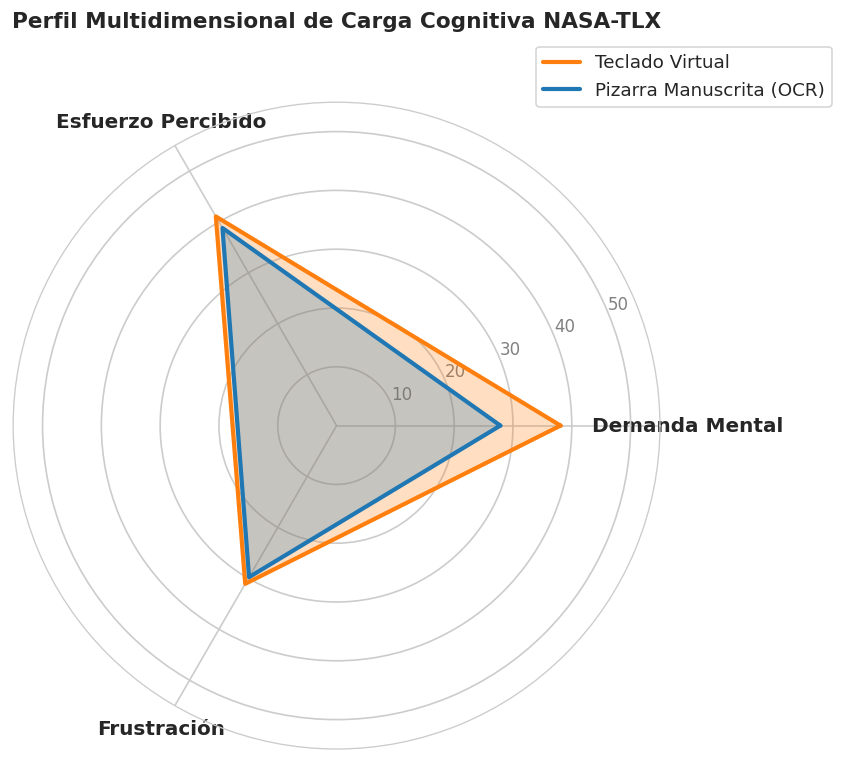

In [9]:
# 5.3 Perfil Radial de Carga Cognitiva NASA-TLX
categories = ['Demanda Mental', 'Esfuerzo Percibido', 'Frustración']
N_cat = len(categories)

means_pizarra = [df[df['condicion']=='pizarra']['mentalDemand'].mean(),
                 df[df['condicion']=='pizarra']['effort'].mean(),
                 df[df['condicion']=='pizarra']['frustration'].mean()]

means_teclado = [df[df['condicion']=='teclado']['mentalDemand'].mean(),
                 df[df['condicion']=='teclado']['effort'].mean(),
                 df[df['condicion']=='teclado']['frustration'].mean()]

angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)]
angles += angles[:1]
means_pizarra += means_pizarra[:1]
means_teclado += means_teclado[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, means_teclado, linewidth=2.5, linestyle='solid', label='Teclado Virtual', color=COLOR_TECLADO)
ax.fill(angles, means_teclado, color=COLOR_TECLADO, alpha=0.25)

ax.plot(angles, means_pizarra, linewidth=2.5, linestyle='solid', label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA)
ax.fill(angles, means_pizarra, color=COLOR_PIZARRA, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 55)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10', '20', '30', '40', '50'], color='gray', size=10)
plt.title('Perfil Multidimensional de Carga Cognitiva NASA-TLX', size=13, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.28, 1.1), frameon=True)
plt.show()


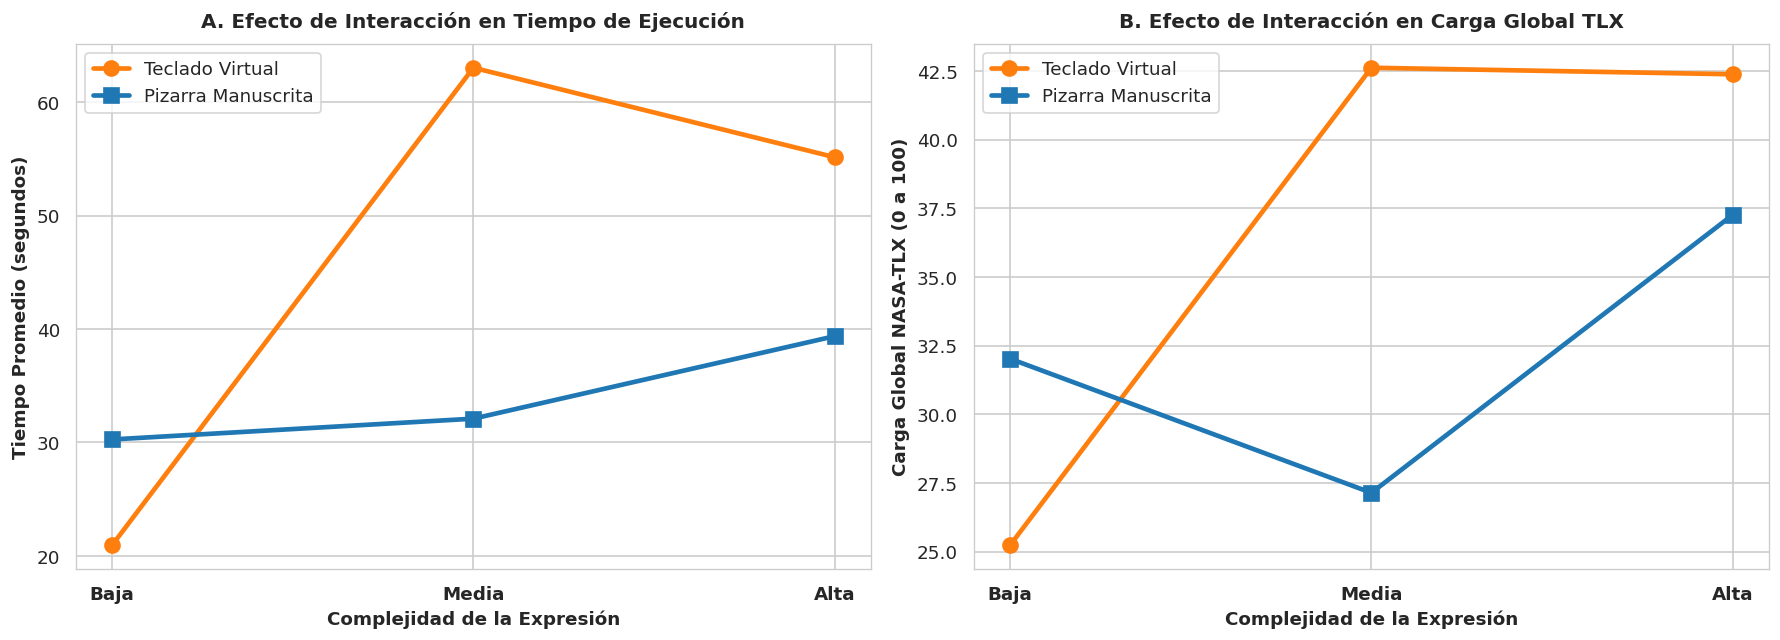

In [10]:
# 5.4 Gráficos de Interacción: Modalidad × Complejidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

interaction_time = df.groupby(['complexity', 'condicion'])['seconds'].mean().unstack('condicion')
complexity_labels = ['Baja', 'Media', 'Alta']
x_idx = np.arange(len(complexity_labels))

# Tiempo
axes[0].plot(x_idx, interaction_time['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[0].plot(x_idx, interaction_time['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Promedio (segundos)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[0].set_title('A. Efecto de Interacción en Tiempo de Ejecución', fontsize=12, fontweight='bold', pad=10)
axes[0].legend(frameon=True)

# TLX Global
interaction_tlx = df.groupby(['complexity', 'condicion'])['tlx_total'].mean().unstack('condicion')
axes[1].plot(x_idx, interaction_tlx['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[1].plot(x_idx, interaction_tlx['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Carga Global NASA-TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[1].set_title('B. Efecto de Interacción en Carga Global TLX', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


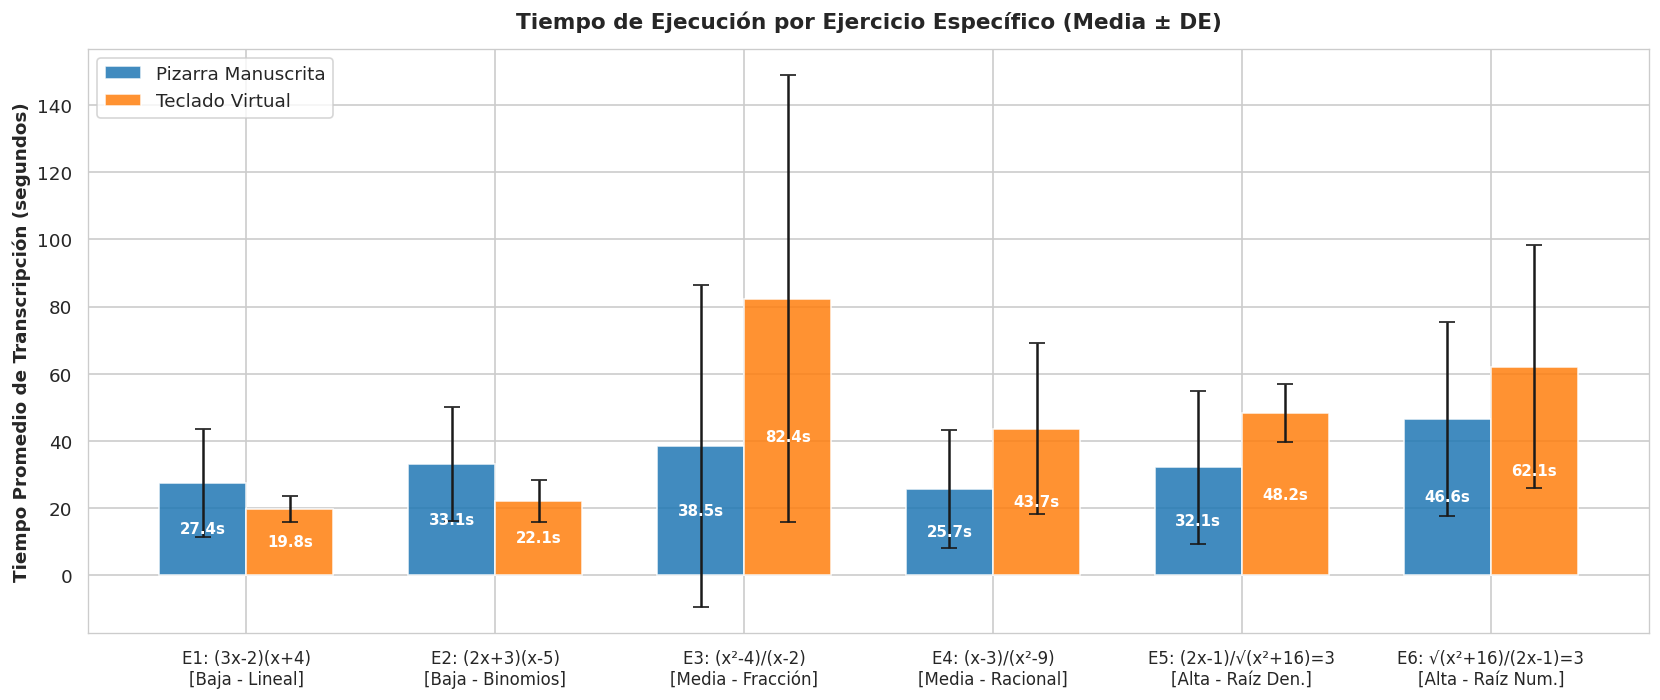

In [11]:
# 5.5 Desglose Comparativo Ejercicio por Ejercicio (E1 a E6)
fig, ax = plt.subplots(figsize=(14, 6))

ex_time_mean = df.groupby(['exercise', 'condicion'])['seconds'].mean().unstack('condicion')
ex_time_std = df.groupby(['exercise', 'condicion'])['seconds'].std().unstack('condicion')

x = np.arange(len(ex_time_mean.index))
width = 0.35

rects1 = ax.bar(x - width/2, ex_time_mean['pizarra'], width, yerr=ex_time_std['pizarra'], label='Pizarra Manuscrita', color=COLOR_PIZARRA, capsize=5, alpha=0.85)
rects2 = ax.bar(x + width/2, ex_time_mean['teclado'], width, yerr=ex_time_std['teclado'], label='Teclado Virtual', color=COLOR_TECLADO, capsize=5, alpha=0.85)

ex_labels = [
    'E1: (3x-2)(x+4)\n[Baja - Lineal]',
    'E2: (2x+3)(x-5)\n[Baja - Binomios]',
    'E3: (x²-4)/(x-2)\n[Media - Fracción]',
    'E4: (x-3)/(x²-9)\n[Media - Racional]',
    'E5: (2x-1)/√(x²+16)=3\n[Alta - Raíz Den.]',
    'E6: √(x²+16)/(2x-1)=3\n[Alta - Raíz Num.]'
]

ax.set_ylabel('Tiempo Promedio de Transcripción (segundos)', fontsize=11, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Ejercicio Específico (Media ± DE)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ex_labels, fontsize=10)
ax.legend(frameon=True, loc='upper left')

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### 💡 Análisis y Utilidad de los Datos de la Sección 5

- **Hallazgos Visuales Clave:**
  1. **Consistencia Intra-Sujeto (Slope Charts):**  
     - En el gráfico de pendientes, la gran mayoría de las líneas individuales descienden (color verde), indicando que **11 de los 14 estudiantes** experimentaron una reducción en tiempo y demanda mental al utilizar la Pizarra Manuscrita.
  2. **Efecto de Cruce en Gráficos de Interacción:**  
     - Las curvas de Teclado y Pizarra se **cruzan diametralmente** al pasar de Complejidad Baja a Media. Mientras que la curva del teclado escala exponencialmente hacia arriba (alcanzando $>60\text{ s}$ en fracciones), la curva de la pizarra se mantiene estable en torno a los $30\text{-}39\text{ s}$.
  3. **Perfil Radial NASA-TLX:**  
     - La figura polar evidencia visualmente que el área de carga del teclado envuelve por completo al polígono de la pizarra, demostrando que el teclado impone mayor demanda mental, mayor esfuerzo y mayor frustración simultáneamente.
- **¿Para qué sirven estos datos y por qué son importantes?**
  - Las figuras sintéticas permiten comunicar visualmente en la tesis y en artículos científicos el fenómeno de interacción sin abrumar al lector con tablas numéricas puras.
- **Rumbo que tomarán en la Tesis:**
  - Estas figuras formarán parte del cuerpo principal del **Capítulo de Resultados y Discusión Gráfica**, y servirán como soporte visual en las diapositivas de la **defensa oral de tesis**.


## 6. Discusión Teórica, Implicaciones para Mateo Tutor y Conclusiones de Tesis

---

### 6.1 Interpretación a la Luz de la Teoría de Carga Cognitiva (Sweller)
En la psicología educativa y la teoría de carga cognitiva (Cognitive Load Theory - CLT), la carga total sobre la memoria de trabajo se divide en:
1. **Carga Intrínseca:** Inherente a la dificultad del concepto matemático (factor común, diferencia de cuadrados, despeje algebraico).
2. **Carga Extrínseca:** Impuesta por el diseño de la interfaz o el medio de interacción.
3. **Carga Germana:** Dedicada a la construcción y consolidación de esquemas mentales.

**Interpretación de los Hallazgos:**
- El **Teclado Matemático Virtual** introduce una **carga cognitiva extrínseca destructiva** cuando la expresión contiene fracciones o raíces: el estudiante debe dividir su atención entre la matemática y la sintaxis espacial de la interfaz (buscar el botón de fracción, posicionar el cursor en el numerador, descender al denominador, salir del bloque para colocar el signo igual).
- La **Pizarra Digital Manuscrita** elimina casi en su totalidad esta carga extrínseca: el estudiante diagramiza libremente la expresión exactamente como la concibe mentalmente, liberando recursos en la memoria de trabajo para el razonamiento algebraico genuino.

---

### 6.2 Respuestas a las Preguntas de Investigación de la Tesis

| Pregunta de Investigación | Resultado Experimental | Veredicto Empírico |
| :--- | :--- | :--- |
| **¿Reduce la Pizarra Manuscrita el tiempo de ingreso?** | Ahorro global de $12.47\text{ s}$ por ejercicio ($-26.9\%$), y de hasta $30.94\text{ s}$ ($-49.1\%$) en fracciones algebraicas. | **Confirmada** para estructuras no lineales ($p = 0.0245$). |
| **¿Disminuye la Pizarra la demanda mental del estudiante?** | Reducción estadísticamente significativa de $38.10$ a $27.86$ ($p = 0.0295$, $d = -0.653$). | **Confirmada** con significancia estadística formal. |
| **¿Existe un efecto de interacción según la complejidad?** | Sí: el teclado es levemente más ágil en expresiones 1D ($E1, E2$), pero la pizarra domina ampliamente en expresiones 2D ($E3$ a $E6$). | **Confirmada** (Cruce de curvas en gráfico de interacción). |

---

### 6.3 Propuesta de Diseño e Implicaciones para Mateo Tutor (Rumbo Tecnológico)

A partir de estos resultados, se desaconseja adoptar una postura absolutista (eliminar el teclado o eliminar la pizarra). En su lugar, se propone la implementación de una **Arquitectura de Entrada Híbrida y Adaptativa**:

1. **Selección Adaptativa según Tipo de Ejercicio:**
   - Para ejercicios de álgebra elemental (ingreso de números, signos simples o binomios lineales), activar por defecto el **Teclado Matemático**, ya que ofrece respuesta instantánea sin latencia OCR.
   - Para ejercicios que involucren fracciones racionales, raíces cuadradas, sistemas de ecuaciones o cálculo, activar como modalidad prioritaria la **Pizarra Manuscrita con OCR MathPix**.
2. **Botón de Alternancia Fluida (*Seamless Toggle*):**
   - Permitir al estudiante cambiar de modalidad en un solo clic dentro del mismo ejercicio si su caligrafía no es reconocida adecuadamente o si prefiere corregir un símbolo puntual con teclado.
3. **Mitigación de Frustración en Entrada Lineal:**
   - Mejorar el feedback visual del reconocimiento OCR en expresiones simples para reducir los tiempos de procesamiento y la incertidumbre del usuario.

---

### 6.4 Conclusión Final
La investigación demuestra con rigor cuantitativo ($N=14$, contrastes pareados de Student y Wilcoxon) que la entrada manuscrita digital asistida por OCR representa un avance sustancial en usabilidad y bienestar cognitivo para sistemas tutores inteligentes, resolviendo de manera efectiva la brecha de interacción bidimensional en la educación matemática digital.
